# Weather NCA — Milestone 1 MVP

A neural cellular automaton that forecasts **z500** (geopotential at 500 hPa) on an
icosahedral mesh. Target: **beat persistence at 24 h lead time.**

This notebook is the full loop — mesh → data → model → training → evaluation → plots.
It runs end-to-end out of the box on synthetic data, and on real ERA5 by flipping one flag.

### Contents
| § | Step | Runtime |
|---|------|---------|
| 1 | Config & setup | instant |
| 2 | Icosahedral mesh + perception operators (**+ sanity check**) | ~30 s |
| 3 | Data: ERA5 → mesh → normalized cache | 2–10 min (cached after) |
| 4 | Dataset & loaders | instant |
| 5 | Model: `WeatherNCA` | instant |
| 6 | Pre-training advection test (**the CFL question**) | ~20 s |
| 7 | Training | ~10–20 min (quick-run defaults) |
| 8 | Evaluation vs persistence & climatology | ~1 min |
| 9 | Visualization: maps, rollouts, spectra | ~1 min |

**Design decisions** are inherited from `milestone-1-plan.md`: icosahedral mesh (not lat-lon),
cell state as `[physical | hidden]`, NCA steps as PDE **sub-steps**, deterministic update
mask, and second-order Markov conditioning.

## 1 · Config & setup

In [154]:
# If anything is missing, uncomment:
# !pip install torch numpy scipy matplotlib
# !pip install xarray zarr gcsfs        # only needed for REAL ERA5

In [155]:
from __future__ import annotations
import os, math, time, json, warnings
from dataclasses import dataclass, field, asdict
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.utils.checkpoint
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
torch.manual_seed(0); np.random.seed(0)

def _pick_device():
    if torch.cuda.is_available(): return "cuda"
    if getattr(getattr(torch.backends, "mps", None), "is_available", lambda: False)(): return "mps"
    return "cpu"
DEVICE = _pick_device()
AMP_DEVICE = DEVICE if DEVICE in ("cuda", "cpu") else "cpu"   # autocast has no mps backend
print(f"torch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")

torch 2.13.0+cu126 | device: cuda
  NVIDIA GeForce GTX 1660 Ti  (6.4 GB)


In [156]:
@dataclass
class Config:
    # ---- geometry -------------------------------------------------------
    n_sub: int = 5              # icosphere subdivisions: 4->2562, 5->10242 (~1 deg), 6->40962

    # ---- cell state: [ physical | hidden ] ------------------------------
    c_phys: int   = 1           # z500 only in Milestone 1
    c_hidden: int = 15          # latent scratch channels
    # static channels: orography, land-sea mask, sin(lat), cos(lat)  -> 4
    c_static: int = 4

    # ---- update network -------------------------------------------------
    hidden_dim: int = 128
    n_layers: int   = 2

    # ---- time integration ----------------------------------------------
    n_substeps: int = 20        # NCA sub-steps per 6 h window  <-- THE CFL BUDGET
                                # 10 is where the CFL sweep plateaus, but max|f| there is
                                # 1.005 vs 0.999 at 40 -> the operator itself amplifies
                                # slightly. Bump to 20 if amplitude creeps up in rollout.
    dt: float       = 0.05      # residual step size
    second_order: bool = True   # feed tendency (x_t - x_{t-1})

    # ---- rollout stability (see findings section 3) ---------------------
    reseed_hidden: bool  = True   # zero the hidden channels between forecast windows
    noise_std: float     = 0.05   # pushforward: perturb the seed during training
    overflow_w: float    = 1e-2   # penalty on |hidden| > 1  (NCA overflow loss)

    # ---- data -----------------------------------------------------------
    use_real_era5: bool = True  # True -> stream ERA5 from WeatherBench-2 (needs gcsfs)
    plot_raw_era5: bool = True  # plot the first raw ERA5 frame before regridding, so an
                                # axis-order/transpose bug is visible before it trains
    wb2_res: str = "240x121"    # "64x32" (fast) | "240x121" (1.5 deg) | "1440x721" (0.25 deg)
    train_years: Tuple[int,...] = (2015, 2016)   # scale up to (1979..2017) for the full protocol
    val_years:   Tuple[int,...] = (2017,)
    test_years:  Tuple[int,...] = (2018,)

    # ---- training -------------------------------------------------------
    train_model: bool  = True
    batch_size: int    = 8
    lr: float          = 1e-3
    epochs: int        = 8
    rollout_epochs: int = 0     # epochs PER curriculum stage. 0 = off.
                                # Runs 2 and 3 both had every fine-tune epoch score
                                # WORSE than single-step on the selection metric, so
                                # none was ever checkpointed. Re-enable only with
                                # rollout_lr_scale another order of magnitude down.
    rollout_windows: Tuple[int,...] = (2, 4, 8)  # curriculum: 1 -> 2 -> 4 -> 8 windows.
                                # Run 2 was stable to 24h and unstable past it, having
                                # never been trained past 24h. The 8-window stage is the
                                # first time the objective sees the regime that blows up.
    rollout_lr_scale: float = 0.03  # fine-tune LR = lr * this. 0.3 diverges: the 2-window
                                    # loss backprops through 2*n_substeps updates.
    ckpt_windows: int  = 8      # ONE fixed val metric for checkpointing, all phases.
                                # Must reach past the useful range or it selects models
                                # that are excellent up to it and diverge after.
    grad_ckpt: bool    = True   # recompute sub-steps in backward: ~n_substeps less
                                # activation memory, ~30% slower. Needed for 8 windows
                                # (80 sub-steps) on 6 GB. Halve batch_size if still OOM.
    grad_clip: float   = 1.0
    amp: bool          = False

    cache_dir: str = "./wnca_cache"

    @property
    def c_state(self) -> int: return self.c_phys + self.c_hidden
    @property
    def c_cond(self)  -> int: return self.c_static + (self.c_phys if self.second_order else 0)

cfg = Config()

# CPU gets smaller defaults so a run finishes in minutes, not hours.
if DEVICE == "cpu":
    cfg.n_sub, cfg.batch_size, cfg.epochs = 4, 2, 4
    print("CPU detected -> reduced defaults (n_sub=4, batch=2, epochs=4)")

os.makedirs(cfg.cache_dir, exist_ok=True)
print(json.dumps({k: str(v) for k, v in asdict(cfg).items()}, indent=1))

{
 "n_sub": "5",
 "c_phys": "1",
 "c_hidden": "15",
 "c_static": "4",
 "hidden_dim": "128",
 "n_layers": "2",
 "n_substeps": "20",
 "dt": "0.05",
 "second_order": "True",
 "reseed_hidden": "True",
 "noise_std": "0.05",
 "overflow_w": "0.01",
 "use_real_era5": "True",
 "plot_raw_era5": "True",
 "wb2_res": "240x121",
 "train_years": "(2015, 2016)",
 "val_years": "(2017,)",
 "test_years": "(2018,)",
 "train_model": "True",
 "batch_size": "8",
 "lr": "0.001",
 "epochs": "8",
 "rollout_epochs": "0",
 "rollout_windows": "(2, 4, 8)",
 "rollout_lr_scale": "0.03",
 "ckpt_windows": "8",
 "grad_ckpt": "True",
 "grad_clip": "1.0",
 "amp": "False",
 "cache_dir": "./wnca_cache"
}


## 2 · Icosahedral mesh & perception operators

Square lat-lon grids distort badly toward the poles, so cells live on a subdivided
icosahedron instead. Perception — the NCA "sensor" — is the mesh analogue of the
`[identity, Sobel_x, Sobel_y, Laplacian]` filter bank used by image NCAs:

$$\nabla_x f_i=\sum_{j\in N(i)} g^x_{ij}(f_j-f_i),\qquad
  \nabla^2 f_i=\sum_{j\in N(i)} \ell_{ij}(f_j-f_i)$$

* **Gradient** — least-squares fit of a linear function to neighbour offsets projected onto
  node *i*'s local east/north tangent plane. The coefficients are the rows of $D^+$.
* **Laplacian** — the **cotangent Laplace–Beltrami** operator from discrete differential
  geometry, $\ell_{ij}=(\cot\alpha_{ij}+\cot\beta_{ij})/2A_i$. (A naive flat-space
  finite difference does *not* converge on a curved surface — it was tried and discarded.)

These coefficients are **geometry, not parameters**: computed once, never trained.

In [157]:
def icosahedron():
    phi = (1.0 + np.sqrt(5.0)) / 2.0
    v = np.array([[-1,phi,0],[1,phi,0],[-1,-phi,0],[1,-phi,0],
                  [0,-1,phi],[0,1,phi],[0,-1,-phi],[0,1,-phi],
                  [phi,0,-1],[phi,0,1],[-phi,0,-1],[-phi,0,1]], dtype=np.float64)
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    f = np.array([[0,11,5],[0,5,1],[0,1,7],[0,7,10],[0,10,11],
                  [1,5,9],[5,11,4],[11,10,2],[10,7,6],[7,1,8],
                  [3,9,4],[3,4,2],[3,2,6],[3,6,8],[3,8,9],
                  [4,9,5],[2,4,11],[6,2,10],[8,6,7],[9,8,1]], dtype=np.int64)
    return v, f

def icosphere(n_sub: int):
    """Recursively subdivide an icosahedron, re-projecting to the unit sphere."""
    v, f = icosahedron(); v = list(v)
    for _ in range(n_sub):
        cache, nf = {}, []
        def mid(a, b):
            key = (min(a,b), max(a,b))
            if key not in cache:
                m = (v[a] + v[b]) / 2.0
                v.append(m / np.linalg.norm(m)); cache[key] = len(v) - 1
            return cache[key]
        for a, b, c in f:
            ab, bc, ca = mid(a,b), mid(b,c), mid(c,a)
            nf += [[a,ab,ca],[b,bc,ab],[c,ca,bc],[ab,bc,ca]]
        f = np.array(nf, dtype=np.int64)
    return np.array(v), f

def edges_from_faces(f):
    e = np.concatenate([f[:,[0,1]], f[:,[1,2]], f[:,[2,0]]], axis=0)
    e = np.unique(np.concatenate([e, e[:,::-1]], axis=0), axis=0)   # both directions
    return e[e[:,0] != e[:,1]]

def tangent_basis(v):
    """Local east / north orthonormal frame at each node."""
    zc = np.broadcast_to(np.array([0.,0.,1.]), v.shape)
    east = np.cross(zc, v)
    n = np.linalg.norm(east, axis=1, keepdims=True)
    east = np.where(n < 1e-8, np.array([1.,0.,0.]), east / np.maximum(n, 1e-30))
    east /= np.linalg.norm(east, axis=1, keepdims=True)
    north = np.cross(v, east); north /= np.linalg.norm(north, axis=1, keepdims=True)
    return east, north

In [158]:
def build_perception_coeffs(v, faces, edges):
    """Per-edge (gx, gy, lap) coefficients + per-node area. Edge k carries j=src -> i=dst."""
    N, E = len(v), len(edges)
    src, dst = edges[:,0], edges[:,1]
    east, north = tangent_basis(v)

    # --- least-squares tangent-plane gradient -----------------------------
    d = v[src] - v[dst]
    d = d - np.sum(d * v[dst], axis=1, keepdims=True) * v[dst]      # project onto tangent plane
    dx = np.sum(d * east[dst], axis=1); dy = np.sum(d * north[dst], axis=1)
    gx = np.zeros(E); gy = np.zeros(E)
    order  = np.argsort(dst, kind="stable")
    bounds = np.searchsorted(dst[order], np.arange(N+1))
    for i in range(N):
        idx = order[bounds[i]:bounds[i+1]]
        W = np.linalg.pinv(np.stack([dx[idx], dy[idx]], axis=1))    # [2,k]
        gx[idx], gy[idx] = W[0], W[1]

    # --- cotangent Laplace-Beltrami + barycentric vertex areas ------------
    cot, area = {}, np.zeros(N)
    for a, b, c in faces:
        p = v[[a,b,c]]
        tri_area = 0.5*np.linalg.norm(np.cross(p[1]-p[0], p[2]-p[0]))
        area[[a,b,c]] += tri_area/3.0
        for i0, i1, iop in ((a,b,c), (b,c,a), (c,a,b)):
            u, w = v[i0]-v[iop], v[i1]-v[iop]
            ct = np.dot(u,w)/max(np.linalg.norm(np.cross(u,w)), 1e-16)
            cot[(i0,i1)] = cot.get((i0,i1), 0.0) + ct
            cot[(i1,i0)] = cot.get((i1,i0), 0.0) + ct
    lap = np.array([cot.get((int(j), int(i)), 0.0) for j, i in edges]) / (2.0*area[dst])
    return gx, gy, lap, area

def build_mesh(cfg):
    path = os.path.join(cfg.cache_dir, f"mesh_sub{cfg.n_sub}.npz")
    if os.path.exists(path):
        m = dict(np.load(path)); print(f"mesh loaded from cache: N={len(m['v'])}"); return m
    t0 = time.time()
    v, faces = icosphere(cfg.n_sub)
    edges = edges_from_faces(faces)
    gx, gy, lap, area = build_perception_coeffs(v, faces, edges)
    m = dict(v=v, faces=faces, edges=edges, gx=gx, gy=gy, lap=lap, area=area,
             lat=np.degrees(np.arcsin(np.clip(v[:,2],-1,1))),
             lon=np.degrees(np.arctan2(v[:,1], v[:,0])))
    np.savez_compressed(path, **m)
    print(f"mesh built in {time.time()-t0:.1f}s: N={len(v)}  E={len(edges)}")
    return m

MESH = build_mesh(cfg)
N_NODES = len(MESH["v"])
R_EARTH = 6.371e6
spacing_km = math.sqrt(4*math.pi*R_EARTH**2/N_NODES)/1e3
print(f"nodes={N_NODES}  edges={len(MESH['edges'])}  mean spacing ~{spacing_km:.0f} km")

mesh loaded from cache: N=10242
nodes=10242  edges=61440  mean spacing ~223 km


### 2.1 Sanity check — do the operators actually differentiate?

*Plan, step 2: "the operator applied to a known analytic field should recover the known
gradient."*

Test on the degree-1 spherical harmonics $f = x, y, z$, whose surface gradient is
$\hat{a} - f\,\hat{r}$ and whose Laplace–Beltrami is exactly $-l(l+1)f = -2f$.
Errors should **shrink** as the mesh refines. If they grow, the operator is wrong.

In [159]:
def apply_edge_op(f, edges, coeff, N):
    """Scatter-add form: out[i] = sum_j coeff_ij (f_j - f_i)."""
    src, dst = edges[:,0], edges[:,1]
    out = np.zeros(N); np.add.at(out, dst, coeff*(f[src]-f[dst])); return out

def operator_convergence(max_sub=None):
    max_sub = max_sub or cfg.n_sub
    print(f"{'n_sub':>5} {'N':>7} | {'grad rel-err':>12} | {'lap rel-err':>12}")
    print("-"*46)
    for ns in range(3, max_sub+1):
        v, faces = icosphere(ns); edges = edges_from_faces(faces); N = len(v)
        gx, gy, lap, _ = build_perception_coeffs(v, faces, edges)
        east, north = tangent_basis(v)
        ge, le = [], []
        for ax in range(3):
            a = np.zeros(3); a[ax] = 1.0
            f = v[:, ax]
            gt = a[None,:] - f[:,None]*v
            tx, ty = np.sum(gt*east,1), np.sum(gt*north,1)
            gxn = apply_edge_op(f, edges, gx, N); gyn = apply_edge_op(f, edges, gy, N)
            ge.append(np.sqrt(np.sum((gxn-tx)**2+(gyn-ty)**2))/np.sqrt(np.sum(tx**2+ty**2)))
            ln = apply_edge_op(f, edges, lap, N)
            le.append(np.linalg.norm(ln + 2.0*f)/np.linalg.norm(2.0*f))
        print(f"{ns:>5} {N:>7} | {np.mean(ge):>12.2e} | {np.mean(le):>12.2e}")

operator_convergence()
print("\nPASS if both columns shrink monotonically down the table.")

n_sub       N | grad rel-err |  lap rel-err
----------------------------------------------
    3     642 |     1.13e-02 |     2.03e-02
    4    2562 |     4.38e-03 |     1.01e-02
    5   10242 |     1.61e-03 |     5.05e-03

PASS if both columns shrink monotonically down the table.


## 3 · Data — ERA5 → mesh → normalized cache

`cfg.use_real_era5 = False` (default) generates a **synthetic** rotating/advecting field:
a few Gaussian vortices carried by a solid-body zonal wind plus a stationary
orographically-locked wave. It has the right character for debugging (advection + a
stationary component) and costs nothing to produce, so the notebook always runs.

`cfg.use_real_era5 = True` streams real z500 from the
[WeatherBench-2](https://weatherbench2.readthedocs.io/en/latest/data-guide.html) ERA5 Zarr
on GCS — 6-hourly, already conservatively regridded. Requires `xarray`, `zarr`, `gcsfs`.

Either way the output is identical downstream: `[T, N_nodes]` normalized z500 + static fields.

In [160]:
WB2_PATHS = {   # verified against the WeatherBench-2 data guide
    "64x32":    "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr",
    "240x121":  "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr",
    "1440x721": "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr",
}

def latlon_to_mesh_weights(lats, lons, mesh_lat, mesh_lon):
    """Bilinear interpolation weights from a regular lat-lon grid onto mesh nodes.
    Returns (idx[N,4], w[N,4]) indexing the FLATTENED [n_lat*n_lon] grid."""
    n_lat, n_lon = len(lats), len(lons)
    asc = lats[0] < lats[-1]
    la = lats if asc else lats[::-1]
    ml = np.clip(mesh_lat, la[0], la[-1])
    i1 = np.clip(np.searchsorted(la, ml), 1, n_lat-1); i0 = i1-1
    ty = (ml - la[i0]) / np.maximum(la[i1]-la[i0], 1e-12)
    if not asc: i0, i1 = n_lat-1-i0, n_lat-1-i1

    lo = np.mod(mesh_lon - lons[0], 360.0)
    dlon = (lons[-1]-lons[0]) / (n_lon-1)
    j0 = np.floor(lo/dlon).astype(int) % n_lon
    j1 = (j0+1) % n_lon
    tx = lo/dlon - np.floor(lo/dlon)

    idx = np.stack([i0*n_lon+j0, i0*n_lon+j1, i1*n_lon+j0, i1*n_lon+j1], axis=1)
    w   = np.stack([(1-ty)*(1-tx), (1-ty)*tx, ty*(1-tx), ty*tx], axis=1)
    return idx.astype(np.int64), w

def regrid_to_mesh(field_2d_stack, idx, w):
    """field_2d_stack: [T, n_lat, n_lon] -> [T, N_nodes]"""
    flat = field_2d_stack.reshape(len(field_2d_stack), -1)
    return np.einsum("tnk,nk->tn", flat[:, idx], w).astype(np.float32)

In [161]:
def load_era5(cfg, years):
    """Stream z500 (+ orography, land-sea mask) from WeatherBench-2 and regrid to the mesh.

    regrid_to_mesh and latlon_to_mesh_weights both assume the grid is laid out as
    (..., latitude, longitude) and flattened row-major as lat*n_lon + lon. WeatherBench-2
    zarr does NOT guarantee that axis order -- several stores are (time, level, longitude,
    latitude). Reading one layout as if it were the other shears each row by a constant
    offset and turns real z500 into diagonal stripes (see findings, the corrupted-ERA5
    run). So every field is explicitly transposed to (time, latitude, longitude) here,
    which makes the contract with the regridder unconditional rather than store-dependent.
    """
    import xarray as xr
    ds = xr.open_zarr(WB2_PATHS[cfg.wb2_res], chunks=None, storage_options={"token":"anon"})
    ds = ds.sel(time=ds.time.dt.year.isin(list(years)))

    z = ds["geopotential"].sel(level=500).transpose("time", "latitude", "longitude")
    lats, lons = ds.latitude.values, ds.longitude.values
    idx, w = latlon_to_mesh_weights(lats, lons, MESH["lat"], MESH["lon"])
    print(f"  streaming {z.sizes['time']} timesteps at {cfg.wb2_res} "
          f"| grid dims {z.dims} shape {z.shape[1:]} ...")

    # SANITY CHECK: real z500 has a smooth spectrum and large mid-latitude waves. A regular
    # diagonal-stripe field, or a sawtooth spectrum, means the axes are still swapped. Plot
    # the first raw native-grid frame once so a transpose bug is visible before it reaches
    # the model. Cheap insurance -- the corrupted run would have been caught here.
    if cfg.plot_raw_era5:
        f0 = np.asarray(z.isel(time=0).values)
        fig, ax = plt.subplots(figsize=(6, 3))
        im = ax.pcolormesh(lons, lats, f0, cmap="RdBu_r", shading="auto")
        ax.set_title(f"raw ERA5 z500, first frame  ({z.dims[1]} x {z.dims[2]})")
        ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
        plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()
        print("   ^ expect a few large mid-latitude troughs/ridges, NOT regular diagonal "
              "stripes. If you see stripes, the axis order is still wrong.")

    z_mesh = regrid_to_mesh(z.values, idx, w)

    def static_or_zeros(name):
        if name in ds:
            arr = ds[name].transpose("latitude", "longitude").values
            return regrid_to_mesh(np.asarray(arr)[None], idx, w)[0]
        return np.zeros(N_NODES, dtype=np.float32)
    orog = static_or_zeros("geopotential_at_surface")
    lsm  = static_or_zeros("land_sea_mask")
    return z_mesh, orog, lsm

def make_synthetic(cfg, n_steps, seed=0):
    """Advecting vortices + a stationary orographic wave. Same interface as load_era5."""
    rng = np.random.default_rng(seed)
    lat = np.radians(MESH["lat"]); lon = np.radians(MESH["lon"])
    orog = (np.exp(-((lat-0.6)**2 + (np.mod(lon+2.0,2*np.pi)-np.pi)**2)/0.25)
            + 0.6*np.exp(-((lat+0.5)**2 + (np.mod(lon-1.0,2*np.pi)-np.pi)**2)/0.30)).astype(np.float32)
    lsm = (orog > 0.25).astype(np.float32)

    n_vort = 6
    lat0 = rng.uniform(-1.0, 1.0, n_vort); lon0 = rng.uniform(0, 2*np.pi, n_vort)
    amp  = rng.uniform(0.5, 1.5, n_vort) * rng.choice([-1,1], n_vort)
    width = rng.uniform(0.25, 0.5, n_vort)
    U = 0.18                                          # rad per 6 h window (~30 m/s at midlats)

    out = np.zeros((n_steps, N_NODES), dtype=np.float32)
    for t in range(n_steps):
        f = 0.8*orog                                  # stationary, terrain-locked component
        for k in range(n_vort):
            lonk = lon0[k] + U*t/np.maximum(np.cos(lat0[k]), 0.3)
            dlon = np.arctan2(np.sin(lon-lonk), np.cos(lon-lonk))
            ang  = np.arccos(np.clip(np.sin(lat)*np.sin(lat0[k])
                                     + np.cos(lat)*np.cos(lat0[k])*np.cos(dlon), -1, 1))
            f = f + amp[k]*np.exp(-(ang/width[k])**2)
        out[t] = f
    out = out*500.0 + 54000.0                         # put it in plausible z500 units (m^2/s^2)
    return out, orog, lsm

  streaming 2924 timesteps at 240x121 | grid dims ('time', 'latitude', 'longitude') shape (121, 240) ...


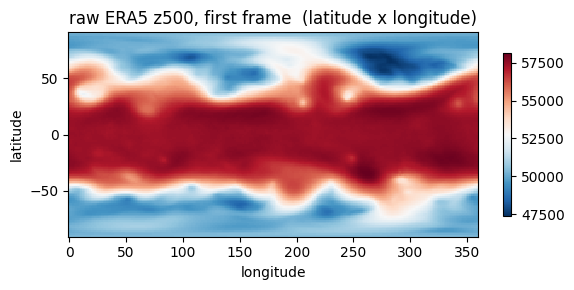

   ^ expect a few large mid-latitude troughs/ridges, NOT regular diagonal stripes. If you see stripes, the axis order is still wrong.
  streaming 1460 timesteps at 240x121 | grid dims ('time', 'latitude', 'longitude') shape (121, 240) ...


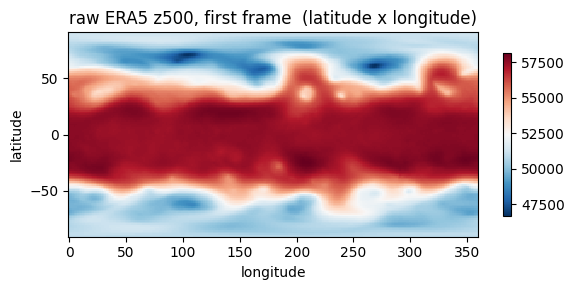

   ^ expect a few large mid-latitude troughs/ridges, NOT regular diagonal stripes. If you see stripes, the axis order is still wrong.
  streaming 1460 timesteps at 240x121 | grid dims ('time', 'latitude', 'longitude') shape (121, 240) ...


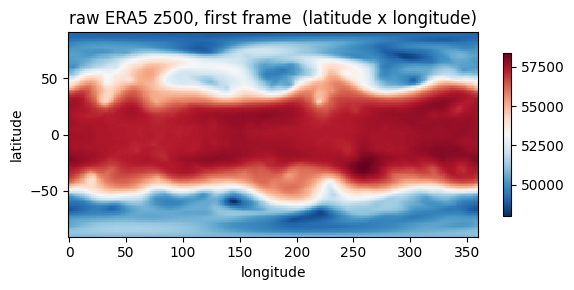

   ^ expect a few large mid-latitude troughs/ridges, NOT regular diagonal stripes. If you see stripes, the axis order is still wrong.
built + cached -> ./wnca_cache\data_era5_240x121_sub5_v2.npz
train (2924, 10242) | val (1460, 10242) | test (1460, 10242)
z500 mean=55600.8  std=2796.0  (m^2/s^2)
static channels: (10242, 4)  (orography, land-sea, sin lat, cos lat)


In [162]:
def build_dataset(cfg):
    # v2: axis-order fix in load_era5 -- old v1/untagged era5 caches are corrupt, skip them
    tag = f"{'era5_'+cfg.wb2_res if cfg.use_real_era5 else 'synth'}_sub{cfg.n_sub}_v2"
    path = os.path.join(cfg.cache_dir, f"data_{tag}.npz")
    if os.path.exists(path):
        d = dict(np.load(path)); print(f"data loaded from cache: {path}"); return d

    if cfg.use_real_era5:
        tr, orog, lsm = load_era5(cfg, cfg.train_years)
        va, _, _      = load_era5(cfg, cfg.val_years)
        te, _, _      = load_era5(cfg, cfg.test_years)
    else:
        n = 1200
        allf, orog, lsm = make_synthetic(cfg, n)
        tr, va, te = allf[:int(.7*n)], allf[int(.7*n):int(.85*n)], allf[int(.85*n):]

    mu, sd = float(tr.mean()), float(tr.std())        # normalization from TRAIN only
    lat_r = np.radians(MESH["lat"])
    static = np.stack([
        (orog - orog.mean())/(orog.std()+1e-8),
        lsm,
        np.sin(lat_r), np.cos(lat_r),
    ], axis=-1).astype(np.float32)                    # [N, 4]

    d = dict(train=(tr-mu)/sd, val=(va-mu)/sd, test=(te-mu)/sd,
             static=static, mu=np.float32(mu), sd=np.float32(sd))
    np.savez_compressed(path, **d)
    print(f"built + cached -> {path}")
    return d

DATA = build_dataset(cfg)
print(f"train {DATA['train'].shape} | val {DATA['val'].shape} | test {DATA['test'].shape}")
print(f"z500 mean={DATA['mu']:.1f}  std={DATA['sd']:.1f}  (m^2/s^2)")
print(f"static channels: {DATA['static'].shape}  (orography, land-sea, sin lat, cos lat)")

## 4 · Dataset & loaders

Second-order Markov means each sample is a **triple**: $(x_{t-1},\;x_t)\to x_{t+k}$.
`n_out` controls how many 6 h windows ahead we supervise — 1 for single-step training,
more for rollout fine-tuning (plan, step 5).

In [163]:
from torch.utils.data import Dataset, DataLoader

class WeatherSeq(Dataset):
    """Yields (prev, cur, targets) where targets covers n_out consecutive 6h windows."""
    def __init__(self, series: np.ndarray, n_out: int = 1):
        self.x = torch.from_numpy(np.ascontiguousarray(series)).float()   # [T, N]
        self.n_out = n_out
    def __len__(self):
        return len(self.x) - self.n_out - 1
    def __getitem__(self, i):
        prev, cur = self.x[i], self.x[i+1]
        tgt = self.x[i+2 : i+2+self.n_out]                # [n_out, N]
        return prev.unsqueeze(-1), cur.unsqueeze(-1), tgt.unsqueeze(-1)

def make_loader(series, n_out=1, shuffle=True, bs=None):
    return DataLoader(WeatherSeq(series, n_out), batch_size=bs or cfg.batch_size,
                      shuffle=shuffle, drop_last=shuffle, num_workers=0)

train_loader = make_loader(DATA["train"], 1, True)
val_loader   = make_loader(DATA["val"],   1, False)
p, c, t = next(iter(train_loader))
print(f"batch: prev{tuple(p.shape)} cur{tuple(c.shape)} target{tuple(t.shape)}")
print(f"{len(train_loader)} train batches | {len(val_loader)} val batches")

batch: prev(8, 10242, 1) cur(8, 10242, 1) target(8, 1, 10242, 1)
365 train batches | 183 val batches


## 5 · Model — `WeatherNCA`

Three time granularities, and keeping them straight is the whole architecture:

| level | what it is | code |
|---|---|---|
| **sub-step** | one residual PDE update; the atomic op | `nca_step` |
| **forecast step** | `n_substeps` sub-steps = one 6 h window | `forecast_step` |
| **rollout** | repeated forecast steps, autoregressive | `rollout` |

The update MLP's output head is **zero-initialized**, so an untrained model is exactly the
identity map — the standard NCA trick that keeps early training from exploding.
The update mask is deterministic ($p=1$), per the plan.

**Hidden channels are re-seeded to zero between forecast windows** when
`cfg.reseed_hidden`. Single-step training (`n_out=1`) only ever presents `hidden = 0`
at the start of a forecast step and then throws the result away, so carrying hidden
state forward at inference feeds the update MLP `c_hidden` channels it has never been
trained on. That mismatch — not blurring, not CFL — was the Milestone 1 blow-up.
Findings section 3 has the evidence. Set it to `False` only alongside rollout training.

In [164]:
class MeshPerception(nn.Module):
    """[identity | grad_x | grad_y | laplacian] per node -> 4C channels."""
    def __init__(self, edges, gx, gy, lap, n_nodes):
        super().__init__()
        self.n_nodes = n_nodes
        self.register_buffer("src", torch.from_numpy(edges[:,0]).long())
        self.register_buffer("dst", torch.from_numpy(edges[:,1]).long())
        for nm, arr in (("gx",gx), ("gy",gy), ("lap",lap)):
            self.register_buffer(nm, torch.from_numpy(arr).float())

    def _agg(self, diff, coeff):
        B, _, C = diff.shape
        out = diff.new_zeros(B, self.n_nodes, C)
        idx = self.dst.view(1,-1,1).expand(B, -1, C)
        return out.scatter_add_(1, idx, diff*coeff.view(1,-1,1))

    def forward(self, x):                                  # x: [B, N, C]
        diff = x[:, self.src, :] - x[:, self.dst, :]       # [B, E, C]
        return torch.cat([x, self._agg(diff, self.gx),
                             self._agg(diff, self.gy),
                             self._agg(diff, self.lap)], dim=-1)

class UpdateRule(nn.Module):
    """Per-cell MLP: perceived neighbourhood + conditioning -> residual delta."""
    def __init__(self, cfg):
        super().__init__()
        layers = [nn.Linear(4*cfg.c_state + cfg.c_cond, cfg.hidden_dim), nn.GELU()]
        for _ in range(cfg.n_layers - 1):
            layers += [nn.Linear(cfg.hidden_dim, cfg.hidden_dim), nn.GELU()]
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(cfg.hidden_dim, cfg.c_state)
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)   # start as identity
    def forward(self, perceived, cond):
        return self.head(self.body(torch.cat([perceived, cond], dim=-1)))

In [165]:
class WeatherNCA(nn.Module):
    def __init__(self, cfg, perception):
        super().__init__()
        self.cfg, self.perceive, self.update = cfg, perception, UpdateRule(cfg)

    # ---- one PDE sub-step (deterministic mask: every cell, every step) ----
    def nca_step(self, state, cond):
        return state + self.cfg.dt * self.update(self.perceive(state), cond)

    # ---- one 6 h window = n_substeps sub-steps (the CFL budget) ----------
    def forecast_step(self, state, static, prev_phys=None):
        cond = self._cond(state, static, prev_phys)        # held fixed across sub-steps
        ckpt = (self.cfg.grad_ckpt and self.training and torch.is_grad_enabled())
        for _ in range(self.cfg.n_substeps):
            if ckpt:
                # store only the sub-step boundaries; recompute the interior in backward
                state = torch.utils.checkpoint.checkpoint(
                    self.nca_step, state, cond, use_reentrant=False)
            else:
                state = self.nca_step(state, cond)
        return state

    # ---- the train/inference consistency fix -----------------------------
    def reseed_hidden(self, state):
        """Zero the hidden channels, keeping the physical ones.

        Single-step training never presents a non-zero hidden state at the start of a
        forecast step. Calling this between windows makes the rollout distribution match
        the training distribution exactly. The second-order conditioning still carries
        the tendency across windows, so less memory is lost than it looks."""
        phys = state[..., :self.cfg.c_phys]
        return torch.cat([phys, torch.zeros_like(state[..., self.cfg.c_phys:])], dim=-1)

    # ---- THE FORWARD -----------------------------------------------------
    def forward(self, state, static, prev_phys=None, steps=1):
        """state [B,N,c_state] | static [B,N,c_static] | prev_phys [B,N,c_phys]
        Advance `steps` forecast windows; returns final state."""
        cur = state[..., :self.cfg.c_phys]
        for _ in range(steps):
            state = self.forecast_step(state, static, prev_phys)
            prev_phys, cur = cur, state[..., :self.cfg.c_phys]
            if self.cfg.reseed_hidden:
                state = self.reseed_hidden(state)
        return state

    def rollout(self, state, static, n_windows, prev_phys=None, return_aux=False):
        """Returns the physical field at every window: [B, n_windows, N, c_phys].

        With return_aux=True also returns the mean overflow of the hidden channels,
        measured BEFORE any re-seeding, so the penalty still bites when re-seeding is on."""
        cur, outs, ovf = state[..., :self.cfg.c_phys], [], state.new_zeros(())
        for _ in range(n_windows):
            state = self.forecast_step(state, static, prev_phys)
            prev_phys, cur = cur, state[..., :self.cfg.c_phys]
            outs.append(cur)
            ovf = ovf + torch.relu(state[..., self.cfg.c_phys:].abs() - 1.0).mean()
            if self.cfg.reseed_hidden:
                state = self.reseed_hidden(state)
        out = torch.stack(outs, dim=1)
        return (out, ovf / n_windows) if return_aux else out

    def _cond(self, state, static, prev_phys):
        if not self.cfg.second_order: return static
        cur = state[..., :self.cfg.c_phys]
        tend = cur - prev_phys if prev_phys is not None else torch.zeros_like(cur)
        return torch.cat([static, tend], dim=-1)

    @staticmethod
    def seed(cfg, phys0):
        """Observed field -> full cell state; hidden channels start at zero."""
        B, N, _ = phys0.shape
        return torch.cat([phys0, phys0.new_zeros(B, N, cfg.c_hidden)], dim=-1)

In [166]:
perception = MeshPerception(MESH["edges"], MESH["gx"], MESH["gy"], MESH["lap"], N_NODES).to(DEVICE)
model = WeatherNCA(cfg, perception).to(DEVICE)

STATIC = torch.from_numpy(DATA["static"]).float().to(DEVICE)          # [N, 4]
AREA   = torch.from_numpy(MESH["area"]).float().to(DEVICE)
AREA_W = (AREA / AREA.mean()).view(1, -1, 1)                          # area weights, mean 1

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
with torch.no_grad():
    s = WeatherNCA.seed(cfg, c.to(DEVICE))
    o = model(s, STATIC.expand(s.shape[0], -1, -1), steps=1)
    r = model.rollout(s, STATIC.expand(s.shape[0], -1, -1), 4)
print(f"state {tuple(s.shape)} -> 1 window {tuple(o.shape)} | 4-window rollout {tuple(r.shape)}")
print(f"identity at init (zero-init head): {torch.allclose(o, s, atol=1e-6)}")

parameters: 27,536
state (8, 10242, 16) -> 1 window (8, 10242, 16) | 4-window rollout (8, 4, 10242, 1)
identity at init (zero-init head): True


## 6 · Pre-training advection test — *the CFL question*

*Plan, step 3: "hand-set the update rule to pure advection with a constant wind and check
the field translates cleanly. This isolates the CFL question from the learning question."*

We bypass the learned MLP entirely and set $\partial f/\partial t = -u\,\nabla_x f$, then
sweep the number of sub-steps. The sub-step count where error stops improving **is** the
CFL budget `n_substeps` should be set to.

In [167]:
@torch.no_grad()
def advection_test(U_ms=30.0, window_s=6*3600.0, substep_counts=(1,2,5,10,20,40)):
    lat = torch.from_numpy(np.radians(MESH["lat"])).float().to(DEVICE)
    lon = torch.from_numpy(np.radians(MESH["lon"])).float().to(DEVICE)
    gx  = perception.gx / R_EARTH                       # unit sphere -> metres
    src, dst = perception.src, perception.dst

    def bump(lon0):
        dlon = torch.atan2(torch.sin(lon-lon0), torch.cos(lon-lon0))
        ang  = torch.acos(torch.clamp(torch.cos(lat)*torch.cos(dlon), -1, 1))
        return torch.exp(-(ang/0.35)**2)

    h = math.sqrt(4*math.pi*R_EARTH**2/N_NODES)
    print(f"mean spacing {h/1e3:.0f} km | U={U_ms} m/s | CFL=1 at {window_s/(h/U_ms):.1f} substeps/6h\n")
    print(f"{'substeps':>9} {'dt (s)':>8} {'CFL':>6} {'RMSE':>9} {'max|f|':>8}")
    print("-"*45)
    truth = bump(torch.tensor(U_ms*window_s/R_EARTH, device=DEVICE))
    results = []
    for ns in substep_counts:
        dt = window_s/ns
        f = bump(torch.tensor(0.0, device=DEVICE)).clone()
        for _ in range(ns):
            g = torch.zeros_like(f).scatter_add_(0, dst, gx*(f[src]-f[dst]))
            f = f - dt*U_ms*g
        rmse = torch.sqrt(((f-truth)**2).mean()).item()
        results.append((ns, rmse))
        print(f"{ns:>9} {dt:>8.0f} {U_ms*dt/h:>6.2f} {rmse:>9.5f} {f.abs().max():>8.3f}"
              + ("   <-- BLOWUP" if f.abs().max() > 10 else ""))
    return results

adv = advection_test()
print(f"\nCurrent cfg.n_substeps = {cfg.n_substeps}. "
      "Pick the smallest count where RMSE has plateaued.")

mean spacing 223 km | U=30.0 m/s | CFL=1 at 2.9 substeps/6h

 substeps   dt (s)    CFL      RMSE   max|f|
---------------------------------------------
        1    21600   2.90   0.00888    1.070
        2    10800   1.45   0.00467    1.038
        5     4320   0.58   0.00209    1.014
       10     2160   0.29   0.00136    1.005
       20     1080   0.15   0.00111    1.001
       40      540   0.07   0.00103    0.999

Current cfg.n_substeps = 20. Pick the smallest count where RMSE has plateaued.


## 7 · Training

Single-step (6 h) supervision with **area-weighted MSE**, then a rollout curriculum
(1 -> 2 -> 4 windows) at a much lower learning rate.

Three things guard autoregressive stability, all off by default in the original scaffold
and all on now:

* **Pushforward noise** (`cfg.noise_std`) perturbs the seeded physical field while the
  target stays clean, so the update rule is trained to *contract* error rather than
  merely to be accurate on the data manifold.
* **Overflow penalty** (`cfg.overflow_w`) on `|hidden| > 1`, from the original NCA paper.
* **One fixed checkpoint metric** — `cfg.ckpt_windows`-window rollout wMSE on val, used
  identically in every phase. The original code compared a 1-step number against a
  2-step number, which makes 'did this epoch improve?' meaningless across a phase change.

Area weights come from the mesh's barycentric vertex areas — on an icosphere these are
nearly uniform, which is exactly why the mesh was chosen over a lat-lon grid.

In [168]:
def area_weighted_mse(pred, target):
    return (AREA_W * (pred - target)**2).mean()

def run_epoch(model, loader, opt=None, n_out=1, scaler=None, noise_std=0.0):
    """Returns the CLEAN area-weighted MSE. The overflow penalty is optimized but not
    reported, so the printed number stays comparable across configurations."""
    train = opt is not None
    model.train(train)
    total, nb = 0.0, 0
    for prev, cur, tgt in loader:
        prev, cur, tgt = prev.to(DEVICE), cur.to(DEVICE), tgt.to(DEVICE)
        st = STATIC.expand(cur.shape[0], -1, -1)
        with torch.set_grad_enabled(train):
            with torch.autocast(AMP_DEVICE, enabled=(scaler is not None)):
                state = WeatherNCA.seed(cfg, cur)
                if train and noise_std > 0:
                    # pushforward trick: analysis-error-sized perturbation on the physical
                    # channels only; the target is unperturbed, so the rule must contract it
                    kick = torch.zeros_like(state)
                    kick[..., :cfg.c_phys] = noise_std * torch.randn_like(kick[..., :cfg.c_phys])
                    state = state + kick
                pred, ovf = model.rollout(state, st, n_out, prev_phys=prev, return_aux=True)
                loss = area_weighted_mse(pred, tgt)
                obj  = loss + cfg.overflow_w * ovf
        if train:
            opt.zero_grad(set_to_none=True)
            if scaler is not None:
                scaler.scale(obj).backward(); scaler.unscale_(opt)
                gn = nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                if torch.isfinite(gn):
                    scaler.step(opt)
                scaler.update()
            else:
                obj.backward()
                gn = nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                if torch.isfinite(gn):
                    opt.step()
        total += loss.item(); nb += 1
    return total/max(nb,1)

In [169]:
if cfg.train_model:
    opt    = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-5)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(cfg.epochs,1))
    if cfg.amp and DEVICE == "cuda":
        try:    scaler = torch.amp.GradScaler(DEVICE)      # torch >= 2.3
        except AttributeError: scaler = torch.cuda.amp.GradScaler()
    else:       scaler = None

    # ONE checkpoint metric for every phase. Never compare a 1-step val loss to a 2-step one.
    ckpt_loader = make_loader(DATA["val"], cfg.ckpt_windows, False)
    def ckpt_metric():
        return run_epoch(model, ckpt_loader, None, cfg.ckpt_windows, None)

    history = {"train": [], "val": [], "sel": [], "phase": []}
    best = float("inf")
    ckpt = os.path.join(cfg.cache_dir, f"best_{time.strftime('%Y%m%d_%H%M')}.pt")
    print(f"checkpoint -> {ckpt}")

    print(f"--- single-step (6h) training  |  selection metric = {cfg.ckpt_windows*6}h rollout ---")
    for ep in range(cfg.epochs):
        t0 = time.time()
        tr = run_epoch(model, train_loader, opt, 1, scaler, noise_std=cfg.noise_std)
        va = run_epoch(model, val_loader,   None, 1, None)
        sel = ckpt_metric()
        sched.step()
        history["train"].append(tr); history["val"].append(va)
        history["sel"].append(sel);  history["phase"].append("1-step")
        flag = ""
        if np.isfinite(sel) and sel < best:
            best = sel; torch.save({"model":model.state_dict(),"cfg":asdict(cfg)}, ckpt); flag = " *"
        print(f"epoch {ep+1:>2}/{cfg.epochs}  train {tr:.5f}  val {va:.5f}  "
            f"sel {sel:.5f}  ({time.time()-t0:.0f}s){flag}")
        if not np.isfinite(tr): 
            raise RuntimeError("Loss is Nan - force stoping training")
else:
    print ("Skipping model training")

checkpoint -> ./wnca_cache\best_20260815_2020.pt
--- single-step (6h) training  |  selection metric = 48h rollout ---
epoch  1/8  train 0.01247  val 0.00389  sel 0.03707  (331s) *
epoch  2/8  train 0.00297  val 0.00185  sel 0.02823  (343s) *
epoch  3/8  train 0.00168  val 0.00184  sel 0.03336  (344s)
epoch  4/8  train 0.00150  val 0.00132  sel 0.02335  (326s) *
epoch  5/8  train 0.00155  val 0.00152  sel 0.03171  (326s)
epoch  6/8  train 0.00137  val 0.00157  sel 0.03967  (326s)
epoch  7/8  train 0.00128  val 0.00132  sel 0.02816  (326s)
epoch  8/8  train 0.00123  val 0.00128  sel 0.02669  (326s)


In [170]:
# --- rollout fine-tuning: curriculum over increasing window counts (plan, step 5) ---
# The original single jump to 2 windows at lr*0.3 diverged: backprop through
# 2 * n_substeps residual updates of an already-amplifying map blows past grad_clip's
# ability to help, and AdamW's normalized step then wrecks the weights in one epoch.
if cfg.train_model and cfg.rollout_epochs > 0:
    for W in cfg.rollout_windows:
        print(f"\n--- rollout fine-tuning ({W} windows = {W*6}h) "
              f"@ lr {cfg.lr*cfg.rollout_lr_scale:.1e} ---")
        tlW  = make_loader(DATA["train"], W, True)
        optW = torch.optim.AdamW(model.parameters(),
                                 lr=cfg.lr*cfg.rollout_lr_scale, weight_decay=1e-5)
        for ep in range(cfg.rollout_epochs):
            t0 = time.time()
            tr  = run_epoch(model, tlW, optW, W, scaler, noise_std=cfg.noise_std)
            va  = run_epoch(model, val_loader, None, 1, None)   # 1-step, for continuity
            sel = ckpt_metric()                                 # SAME metric as phase 1
            history["train"].append(tr); history["val"].append(va)
            history["sel"].append(sel);  history["phase"].append(f"{W}-step")
            flag = ""
            if np.isfinite(sel) and sel < best:
                best = sel
                torch.save({"model":model.state_dict(),"cfg":asdict(cfg)}, ckpt); flag = " *"
            print(f"epoch {ep+1:>2}/{cfg.rollout_epochs}  train {tr:.5f}  val {va:.5f}  "
                  f"sel {sel:.5f}  ({time.time()-t0:.0f}s){flag}")

    print(f"\ntraining done — best {cfg.ckpt_windows*6}h rollout wMSE {best:.5f}")
    print("§8.0 loads the checkpoint; no restore here.")

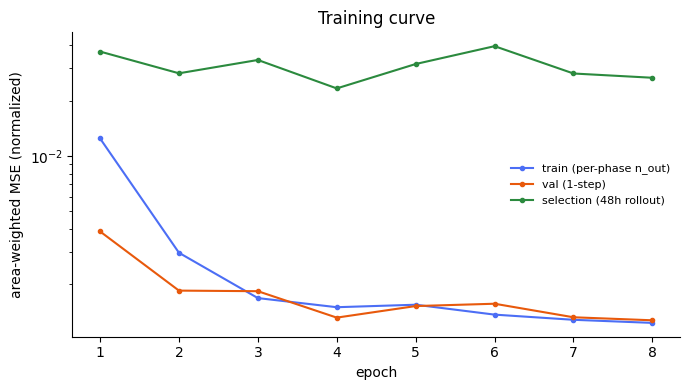

In [171]:
if cfg.train_model:
    fig, ax = plt.subplots(figsize=(7,4))
    ep = np.arange(1, len(history["train"])+1)
    ax.plot(ep, history["train"], "-o", ms=3, label="train (per-phase n_out)", color="#4C6EF5")
    ax.plot(ep, history["val"],   "-o", ms=3, label="val (1-step)",            color="#E8590C")
    ax.plot(ep, history["sel"],   "-o", ms=3, label=f"selection ({cfg.ckpt_windows*6}h rollout)",
            color="#2B8A3E")
    # mark every phase boundary, not just the first
    prev = None
    for k, ph in enumerate(history["phase"]):
        if prev is not None and ph != prev:
            ax.axvline(k+0.5, ls="--", c="0.6", lw=1)
            ax.text(k+0.6, max(history["train"])*0.9, ph, fontsize=8, color="0.4")
        prev = ph
    ax.set_xlabel("epoch"); ax.set_ylabel("area-weighted MSE (normalized)")
    ax.set_yscale("log"); ax.legend(frameon=False, fontsize=8); ax.set_title("Training curve")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()
else:
    print("Skipping training this session — nothing to plot")

## 8 · Evaluation — the Milestone 1 bar

**Primary: RMSE below persistence at 24 h.** Persistence (tomorrow = today) is a low bar;
failing it means the locality assumption is wrong.

Secondary, per the plan: RMSE vs climatology, rollout stability to 7 days, and a power
spectrum check for blurring (the expected failure mode of deterministic MSE training).
All RMSEs are reported in physical units (m²/s²) and area-weighted.

### 8.0 · Load the trained checkpoint

Cell 19 rebuilds `model` as a **zero-init identity map**. Re-running it after training, or
restarting the kernel and jumping straight here, silently evaluates an untrained model —
which reproduces persistence exactly and produces an evaluation table that looks plausible
until you notice the skill column is 0.0% at every lead. The assert at the end of this cell
is there so that never passes silently again.

In [173]:
# --- load the trained checkpoint --------------------------------------------------
import glob
ckpts = sorted(glob.glob(os.path.join(cfg.cache_dir, "best_*.pt")))
if not ckpts:                                    # fall back to any legacy best.pt
    ckpts = glob.glob(os.path.join(cfg.cache_dir, "best.pt"))
if not ckpts:
    raise FileNotFoundError(f"no checkpoint in {cfg.cache_dir} -- run training first")
ckpt_path = ckpts[-1]                            # newest by timestamp

try:
    blob = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
except TypeError:                                    # torch < 2.0
    blob = torch.load(ckpt_path, map_location=DEVICE)

saved = blob.get("cfg", {})

# architecture fields must match the live model or the load is meaningless
ARCH = ("n_sub", "c_phys", "c_hidden", "c_static", "hidden_dim", "n_layers")
bad = {k: (saved[k], getattr(cfg, k)) for k in ARCH
       if k in saved and saved[k] != getattr(cfg, k)}
if bad:
    raise RuntimeError(f"checkpoint/config architecture mismatch (saved, live): {bad}")

model.load_state_dict(blob["model"])
model.to(DEVICE).eval()

# behavioural fields are NOT enforced -- differing reseed_hidden is a valid ablation,
# not an error -- but print them so the evaluation stays interpretable
print(f"loaded {ckpt_path}  ({time.ctime(os.path.getmtime(ckpt_path))})")
for k in ("n_substeps", "dt", "second_order", "reseed_hidden", "noise_std", "overflow_w"):
    print(f"  {k:<14} trained {str(saved.get(k, 'n/a')):<8} | evaluating {getattr(cfg, k, 'n/a')}")

h = model.update.head.weight.norm().item()
print(f"\nhead |W| = {h:.4e}")
assert h > 0, "head weights are zero -- this checkpoint is an untrained model"

loaded ./wnca_cache\best_20260815_2020.pt  (Sat Aug 15 20:43:18 2026)
  n_substeps     trained 20       | evaluating 20
  dt             trained 0.05     | evaluating 0.05
  second_order   trained True     | evaluating True
  reseed_hidden  trained True     | evaluating True
  noise_std      trained 0.05     | evaluating 0.05
  overflow_w     trained 0.01     | evaluating 0.01

head |W| = 5.5854e-01


In [174]:
@torch.no_grad()
def evaluate(series, max_windows=28, n_samples=32):
    """Area-weighted RMSE in m^2/s^2 for model / persistence / climatology, per lead time."""
    model.eval()
    sd = float(DATA["sd"])
    T = len(series)
    max_windows = min(max_windows, T-4)                  # guard against short splits
    n_starts = max(1, min(n_samples, T-max_windows-3))
    starts = np.unique(np.linspace(1, T-max_windows-2, n_starts).astype(int))
    x = torch.from_numpy(series).float()
    clim = torch.from_numpy(DATA["train"].mean(0)).float().to(DEVICE)   # climatology from TRAIN

    err_m = np.zeros(max_windows); err_p = np.zeros(max_windows); err_c = np.zeros(max_windows)
    for s0 in starts:
        prev = x[s0-1].unsqueeze(0).unsqueeze(-1).to(DEVICE)
        cur  = x[s0  ].unsqueeze(0).unsqueeze(-1).to(DEVICE)
        tgt  = x[s0+1 : s0+1+max_windows].unsqueeze(0).unsqueeze(-1).to(DEVICE)
        st   = STATIC.unsqueeze(0)
        pred = model.rollout(WeatherNCA.seed(cfg, cur), st, max_windows, prev_phys=prev)
        w = AREA_W.unsqueeze(0)
        # accumulate MSE and sqrt at the end -> pooled RMSE (mean-of-RMSE is biased low)
        def mse(a, b): return (w*(a-b)**2).mean(dim=(0,2,3)).cpu().numpy()
        err_m += mse(pred, tgt)
        err_p += mse(cur.unsqueeze(1).expand_as(tgt), tgt)
        err_c += mse(clim.view(1,1,-1,1).expand_as(tgt), tgt)
    n = len(starts)
    return (np.sqrt(err_m/n)*sd, np.sqrt(err_p/n)*sd, np.sqrt(err_c/n)*sd)

m_err, p_err, c_err = evaluate(DATA["test"])
leads = (np.arange(len(m_err))+1)*6

print(f"{'lead':>7} {'NCA':>10} {'persist':>10} {'clim':>10} {'skill vs persist':>17}")
print("-"*60)
for h in (6, 12, 24, 48, 72, 120, 168):
    if h//6 <= len(m_err):
        i = h//6 - 1
        skill = 1 - m_err[i]/p_err[i]
        print(f"{h:>5}h  {m_err[i]:>10.1f} {p_err[i]:>10.1f} {c_err[i]:>10.1f} {skill:>16.1%}")

i24 = 24//6 - 1
verdict = "PASS" if m_err[i24] < p_err[i24] else "FAIL"
print(f"\nMILESTONE 1 PRIMARY BAR (24h RMSE < persistence): {verdict}")
print(f"  NCA {m_err[i24]:.1f}  vs  persistence {p_err[i24]:.1f}  (m^2/s^2)")

   lead        NCA    persist       clim  skill vs persist
------------------------------------------------------------
    6h       102.5      229.0     1068.4            55.2%
   12h       178.4      367.7     1071.0            51.5%
   24h       344.7      593.9     1072.7            42.0%
   48h       657.7      830.5     1077.4            20.8%
   72h       889.9      941.7     1074.5             5.5%
  120h      1172.6     1005.6     1069.7           -16.6%
  168h      1367.2     1041.0     1066.6           -31.3%

MILESTONE 1 PRIMARY BAR (24h RMSE < persistence): PASS
  NCA 344.7  vs  persistence 593.9  (m^2/s^2)


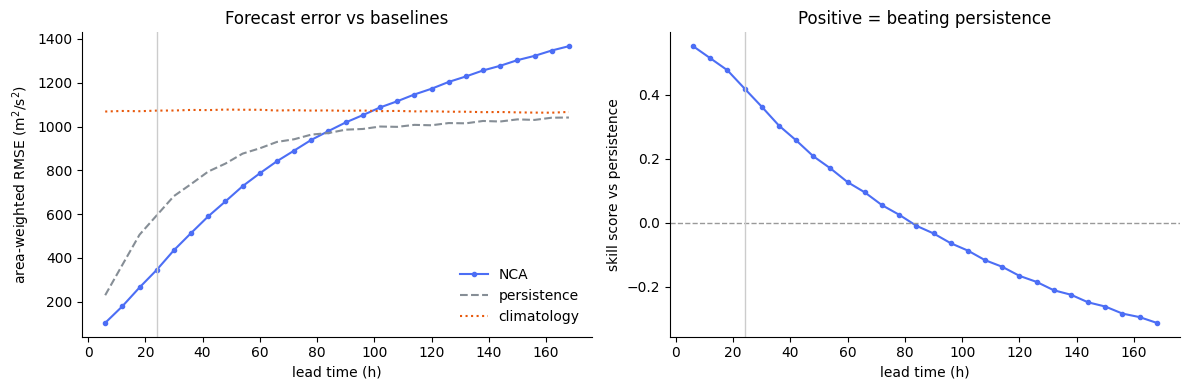

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(leads, m_err, "-o", ms=3, label="NCA",         color="#4C6EF5")
ax.plot(leads, p_err, "--", label="persistence",       color="#868E96")
ax.plot(leads, c_err, ":",  label="climatology",       color="#E8590C")
ax.axvline(24, c="0.8", lw=1)
ax.set_xlabel("lead time (h)"); ax.set_ylabel("area-weighted RMSE (m$^2$/s$^2$)")
ax.set_title("Forecast error vs baselines"); ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)

ax = axes[1]
ax.plot(leads, 1 - m_err/p_err, "-o", ms=3, color="#4C6EF5")
ax.axhline(0, c="0.6", lw=1, ls="--")
ax.axvline(24, c="0.8", lw=1)
ax.set_xlabel("lead time (h)"); ax.set_ylabel("skill score vs persistence")
ax.set_title("Positive = beating persistence")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

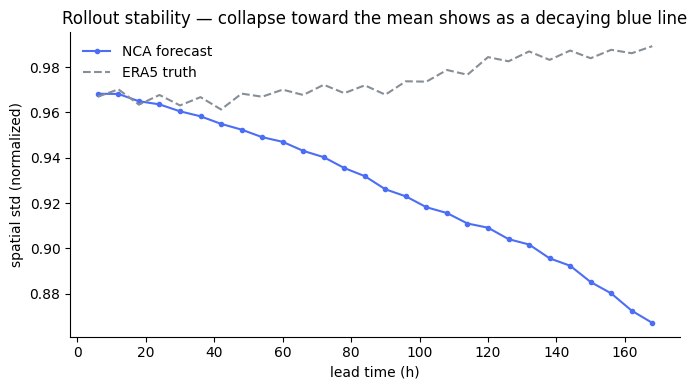

variance ratio at 168h: 0.88  (stable)


In [176]:
@torch.no_grad()
def rollout_stability(series, n_windows=28):
    n_windows = min(n_windows, len(series)-3)
    """Plan risk-check: does a long rollout blow up, or collapse toward the mean?"""
    model.eval()
    cur  = torch.from_numpy(series[1]).float().view(1,-1,1).to(DEVICE)
    prev = torch.from_numpy(series[0]).float().view(1,-1,1).to(DEVICE)
    pred = model.rollout(WeatherNCA.seed(cfg, cur), STATIC.unsqueeze(0), n_windows, prev_phys=prev)
    pstd = pred.std(dim=2).squeeze(0).squeeze(-1).cpu().numpy()
    tstd = torch.from_numpy(series[2:2+n_windows]).float().std(dim=1).numpy()
    return pstd, tstd

pstd, tstd = rollout_stability(DATA["test"])
fig, ax = plt.subplots(figsize=(7,4))
L = (np.arange(len(pstd))+1)*6
ax.plot(L, pstd, "-o", ms=3, label="NCA forecast", color="#4C6EF5")
ax.plot(L[:len(tstd)], tstd, "--", label="ERA5 truth", color="#868E96")
ax.set_xlabel("lead time (h)"); ax.set_ylabel("spatial std (normalized)")
ax.set_title("Rollout stability — collapse toward the mean shows as a decaying blue line")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

drift = pstd[-1]/max(tstd[-1] if len(tstd) else 1, 1e-8)
print(f"variance ratio at {L[-1]}h: {drift:.2f}  "
      f"({'blurring/collapse' if drift < 0.7 else 'blow-up' if drift > 1.5 else 'stable'})")

### 8.1 · Which instability is it?

Three curves, in order of how much to trust them.

**Perturbation growth** rolls out from two nearly-identical starts and watches the gap. No
linearization, no finite differences — it measures what the model actually does. ~1.00 per
window means the operator is neutrally stable and any remaining error growth is *systematic*
(bias, blurring) rather than amplification. Above ~1.05 the operator itself is the problem.

**Error growth on a log axis** mixes both effects. A straight line is exponential
amplification; a concave, saturating curve is drift. Read the per-window ratios, not a
geometric mean over all windows — the first window is routinely anomalous.

**Hidden-channel RMS.** Unbounded growth means the automaton is driving its latent state
off-distribution, a failure single-step training is structurally blind to.

A fourth diagnostic, a power-iteration spectral radius, was tried and removed. Its
finite-difference Jacobian-vector products sat on the float32 noise floor, so the answer
scaled inversely with the step size (6.5 / 36.3 / 290 at eps 1e-2 / 1e-3 / 1e-4) and the
reported value was noise. See findings §5.

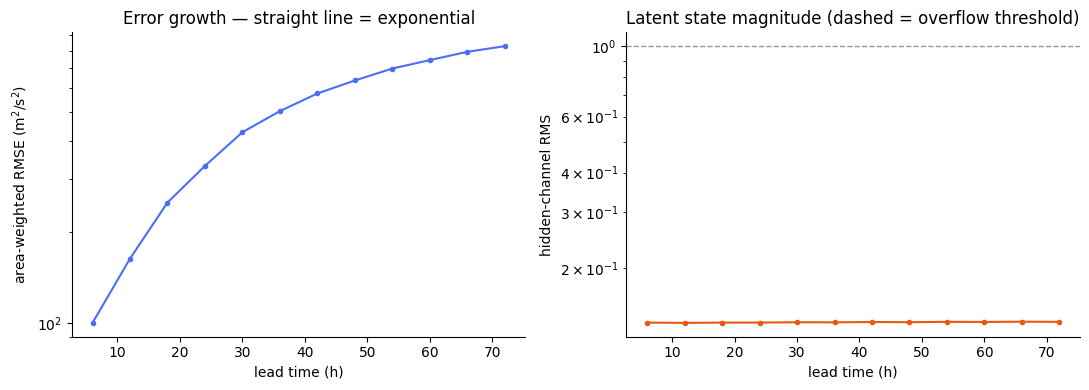

per-window error growth (the tail is what matters; window 1 is often anomalous):
  12h x1.63  18h x1.53  24h x1.32  30h x1.29  36h x1.17  42h x1.14  48h x1.10  54h x1.10  60h x1.07  66h x1.07  72h x1.04
geometric mean excluding window 1: x1.176 per 6h window
hidden RMS: 0.135 at +6h -> 0.135 at +72h
  x>2 per window means the forecast operator is amplifying, not drifting.


In [177]:
@torch.no_grad()
def growth_diagnostics(series, start=5, n=12):
    """Per-window error growth and hidden-channel magnitude for one rollout."""
    model.eval()
    aw   = AREA_W                       # already [1, N, 1]
    sd   = float(DATA["sd"])
    prev = torch.from_numpy(series[start-1]).float().view(1,-1,1).to(DEVICE)
    cur  = torch.from_numpy(series[start]).float().view(1,-1,1).to(DEVICE)
    state, p, c = WeatherNCA.seed(cfg, cur), prev, cur
    n = min(n, len(series)-start-1)
    errs, hrms = [], []
    for k in range(n):
        state = model.forecast_step(state, STATIC.unsqueeze(0), p)
        p, c = c, state[..., :cfg.c_phys]
        t = torch.from_numpy(series[start+k+1]).float().view(1,-1,1).to(DEVICE)
        errs.append(float(torch.sqrt((aw*(c-t)**2).mean())) * sd)
        hrms.append(float(state[..., cfg.c_phys:].pow(2).mean().sqrt()))
        if cfg.reseed_hidden:
            state = model.reseed_hidden(state)
    return np.array(errs), np.array(hrms)

errs, hrms = growth_diagnostics(DATA["test"])
L = (np.arange(len(errs))+1)*6

fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].semilogy(L, errs, "-o", ms=3, color="#4C6EF5")
axes[0].set_xlabel("lead time (h)"); axes[0].set_ylabel("area-weighted RMSE (m$^2$/s$^2$)")
axes[0].set_title("Error growth — straight line = exponential")
axes[1].semilogy(L, np.maximum(hrms, 1e-12), "-o", ms=3, color="#E8590C")
axes[1].axhline(1.0, ls="--", c="0.6", lw=1)
axes[1].set_xlabel("lead time (h)"); axes[1].set_ylabel("hidden-channel RMS")
axes[1].set_title("Latent state magnitude (dashed = overflow threshold)")
for a in axes: a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

ratios = errs[1:]/np.maximum(errs[:-1], 1e-12)
print("per-window error growth (the tail is what matters; window 1 is often anomalous):")
print("  " + "  ".join(f"{L[i+1]:.0f}h x{r:.2f}" for i, r in enumerate(ratios)))
tail = ratios[1:][np.isfinite(ratios[1:]) & (ratios[1:] > 0)]
g = float(np.exp(np.mean(np.log(tail)))) if len(tail) else float("nan")
print(f"geometric mean excluding window 1: x{g:.3f} per 6h window")
print(f"hidden RMS: {hrms[0]:.3f} at +6h -> {hrms[-1]:.3f} at +{len(hrms)*6}h")
print("  x>2 per window means the forecast operator is amplifying, not drifting.")

In [178]:
@torch.no_grad()
def perturbation_growth(series, start=5, n=12, amp=1e-3, mode=None):
    """Finite-amplitude growth: roll out from x0 and from x0+delta, track ||difference||.

    This is the diagnostic that has been reliable. No linearization, no finite differences
    -- just two rollouts from nearly-identical starts. ~1.00 per window means the operator
    is neutrally stable and any remaining error growth is systematic (bias, blurring)
    rather than amplified. Above ~1.05 the operator itself is the problem.
    """
    model.eval()
    st = STATIC.unsqueeze(0)
    prev = torch.from_numpy(series[start-1]).float().view(1,-1,1).to(DEVICE)
    cur  = torch.from_numpy(series[start]).float().view(1,-1,1).to(DEVICE)
    x0 = WeatherNCA.seed(cfg, cur)

    d = torch.zeros_like(x0)
    src = torch.randn_like(x0[..., :cfg.c_phys]) if mode is None else mode[..., :cfg.c_phys]
    d[..., :cfg.c_phys] = amp * src / src.norm()
    a, b, pa, pb, out = x0, x0 + d, prev, prev, []
    for _ in range(n):
        a = model.forecast_step(a, st, pa); b = model.forecast_step(b, st, pb)
        pa, pb = a[..., :cfg.c_phys], b[..., :cfg.c_phys]
        out.append(float((b - a).norm()))
        if cfg.reseed_hidden:
            a, b = model.reseed_hidden(a), model.reseed_hidden(b)
    g = np.array(out)
    print("per-window growth:", "  ".join(f"{r:.2f}" for r in g[1:]/g[:-1]))
    return g

g_rand = perturbation_growth(DATA["test"], mode=None)
print(f"\nmean growth excluding window 1: "
      f"x{np.exp(np.mean(np.log(g_rand[2:]/g_rand[1:-1]))):.3f}")
print("  ~1.00 -> neutrally stable      >1.05 -> the operator is still amplifying")

per-window growth: 4.54  1.65  1.19  1.08  1.09  1.04  1.05  1.05  1.03  1.06  1.04

mean growth excluding window 1: x1.116
  ~1.00 -> neutrally stable      >1.05 -> the operator is still amplifying


## 9 · Visualization — look at the actual maps

Mesh values are scattered back to a regular lat-lon grid (nearest-neighbour) purely for
display. Blurring — the expected failure mode of deterministic MSE training — is much
easier to *see* here than to read off an RMSE table.

In [179]:
from scipy.spatial import cKDTree

_XYZ = MESH["v"]
_GLAT = np.linspace(-89.5, 89.5, 180); _GLON = np.linspace(-180, 179, 360)
_MLON, _MLAT = np.meshgrid(np.radians(_GLON), np.radians(_GLAT))
_GXYZ = np.stack([np.cos(_MLAT)*np.cos(_MLON), np.cos(_MLAT)*np.sin(_MLON),
                  np.sin(_MLAT)], axis=-1).reshape(-1,3)
_NN = cKDTree(_XYZ).query(_GXYZ)[1].reshape(len(_GLAT), len(_GLON))

def to_grid(node_vals):
    return np.asarray(node_vals).reshape(-1)[_NN]

def show_map(ax, vals, title, vmin=None, vmax=None, cmap="RdBu_r"):
    im = ax.imshow(to_grid(vals), origin="lower", extent=[-180,180,-90,90],
                   cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10); ax.set_xticks([-180,0,180]); ax.set_yticks([-90,0,90])
    return im

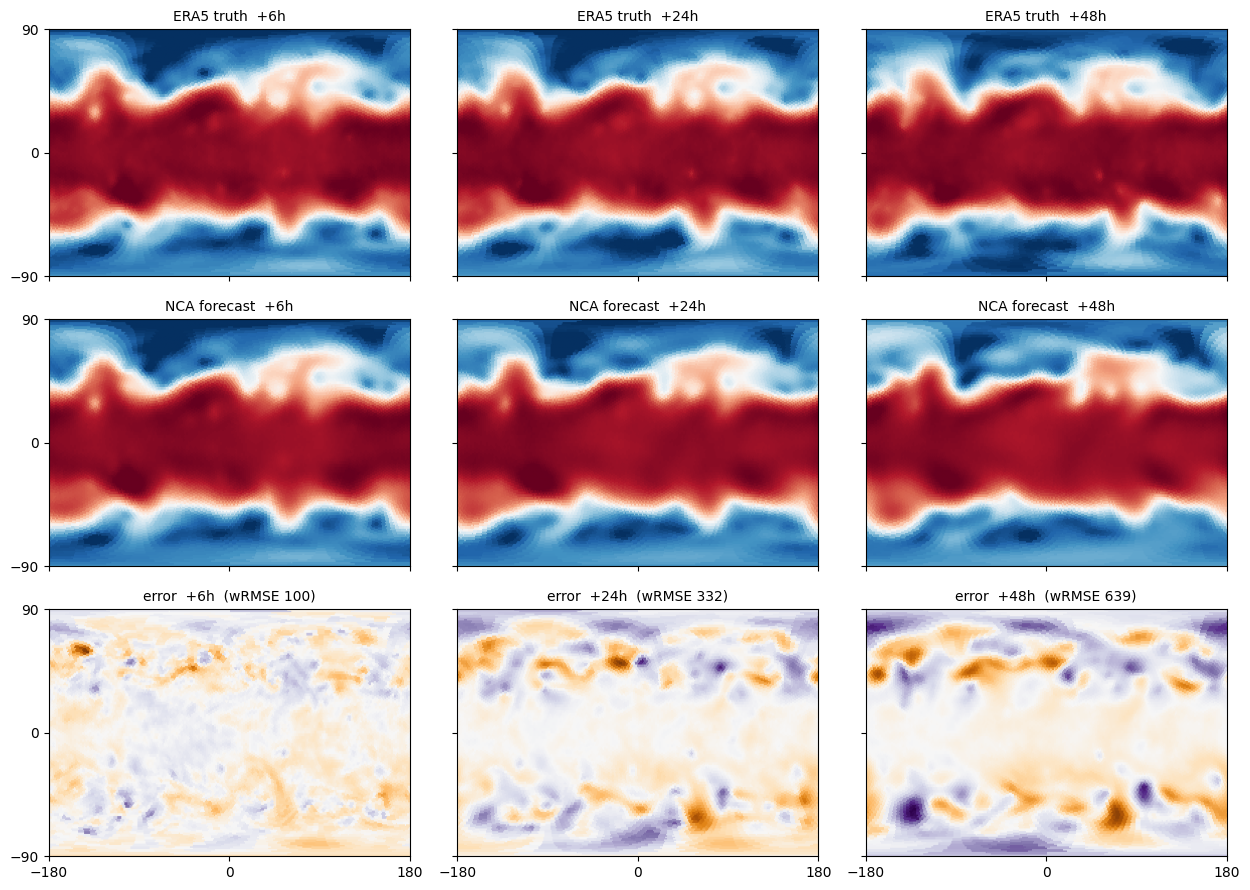

In [180]:
@torch.no_grad()
def show_forecast(series, start=5, leads=(1, 4, 8)):
    """Rows: truth / NCA forecast / error. Columns: lead times."""
    model.eval()
    mu, sd = float(DATA["mu"]), float(DATA["sd"])
    prev = torch.from_numpy(series[start-1]).float().view(1,-1,1).to(DEVICE)
    cur  = torch.from_numpy(series[start]).float().view(1,-1,1).to(DEVICE)
    n = max(leads)
    pred = model.rollout(WeatherNCA.seed(cfg, cur), STATIC.unsqueeze(0), n,
                         prev_phys=prev).squeeze(0).squeeze(-1).cpu().numpy()   # [n, N]

    fig, axes = plt.subplots(3, len(leads), figsize=(4.2*len(leads), 9), squeeze=False)
    lo, hi = np.percentile(series[start:start+n+1]*sd+mu, [1, 99])
    for k, L in enumerate(leads):
        truth = series[start+L]*sd + mu
        fc    = pred[L-1]*sd + mu
        show_map(axes[0,k], truth, f"ERA5 truth  +{L*6}h", lo, hi)
        show_map(axes[1,k], fc,    f"NCA forecast  +{L*6}h", lo, hi)
        e = fc - truth
        v = np.abs(e).max()
        aw = MESH["area"]/MESH["area"].mean()          # match the area-weighted headline metric
        show_map(axes[2,k], e, f"error  +{L*6}h  (wRMSE {np.sqrt((aw*e**2).mean()):.0f})",
                 -v, v, cmap="PuOr")
    for a in axes.flat: a.label_outer()
    plt.tight_layout(); plt.show()

show_forecast(DATA["test"])

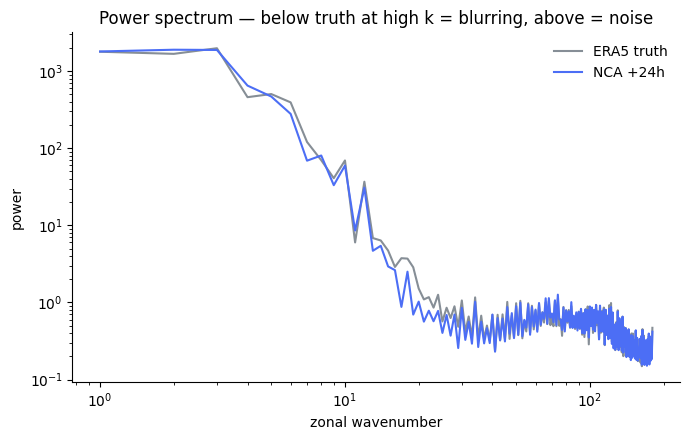

high-wavenumber power, forecast/truth: 100.9%  ->  comparable


In [181]:
@torch.no_grad()
def power_spectrum_check(series, start=5, lead=4):
    """Zonal power spectrum. BELOW truth at high k = blurring (the MSE failure mode);
    ABOVE truth = grid-scale noise or amplitude blow-up (the autoregressive one).
    The original one-sided message read a 14x EXCESS as if it were over-smoothing."""
    model.eval()
    prev = torch.from_numpy(series[start-1]).float().view(1,-1,1).to(DEVICE)
    cur  = torch.from_numpy(series[start]).float().view(1,-1,1).to(DEVICE)
    pred = model.rollout(WeatherNCA.seed(cfg, cur), STATIC.unsqueeze(0), lead,
                         prev_phys=prev).squeeze(0).squeeze(-1).cpu().numpy()

    def zonal_spectrum(nodes):
        g = to_grid(nodes)                       # [n_lat, n_lon]
        w = np.cos(np.radians(_GLAT))[:, None]   # area weight by latitude
        p = np.abs(np.fft.rfft(g - g.mean(axis=1, keepdims=True), axis=1))**2
        return (p*w).sum(0)/w.sum()

    sp_t = zonal_spectrum(series[start+lead]); sp_f = zonal_spectrum(pred[lead-1])
    k = np.arange(len(sp_t))
    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.loglog(k[1:], sp_t[1:], label="ERA5 truth", color="#868E96")
    ax.loglog(k[1:], sp_f[1:], label=f"NCA +{lead*6}h", color="#4C6EF5")
    ax.set_xlabel("zonal wavenumber"); ax.set_ylabel("power")
    ax.set_title("Power spectrum — below truth at high k = blurring, above = noise")
    ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()
    hi = slice(len(k)//3, None)
    r = sp_f[hi].sum()/sp_t[hi].sum()
    verdict = ("over-smooth / blurring"        if r < 0.5 else
               "grid-scale noise or blow-up"   if r > 2.0 else
               "comparable")
    print(f"high-wavenumber power, forecast/truth: {r:.1%}  ->  {verdict}")

power_spectrum_check(DATA["test"])

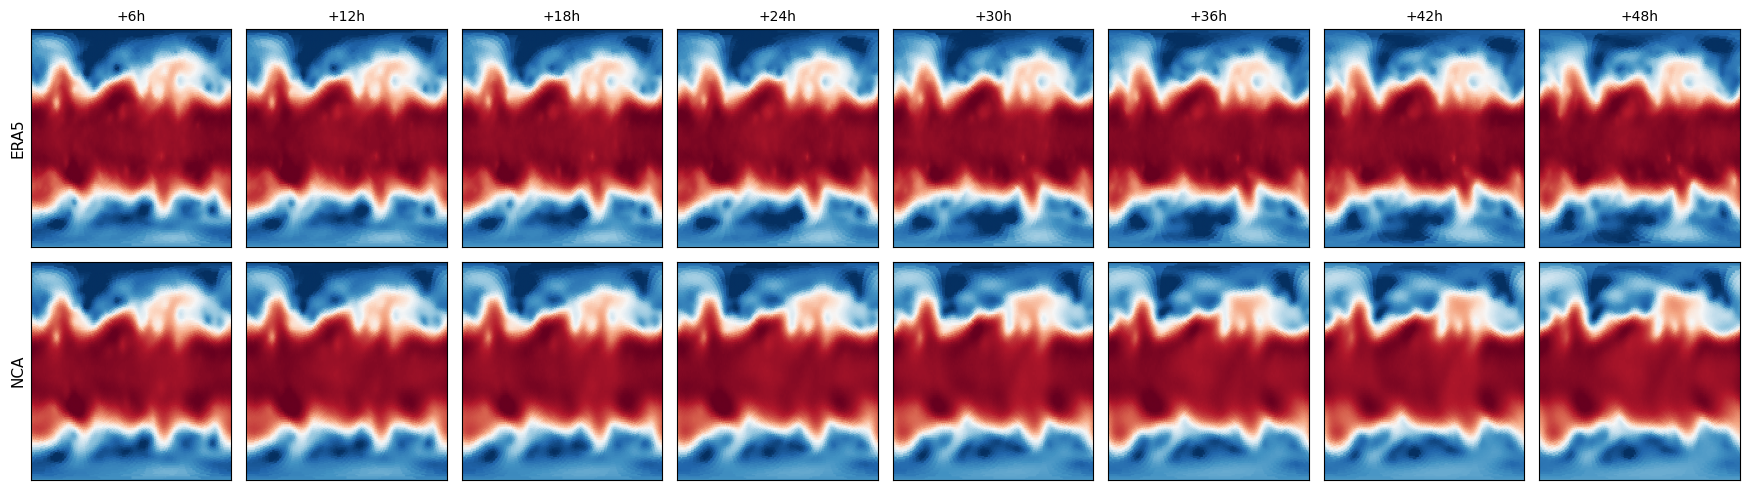

In [182]:
@torch.no_grad()
def show_rollout(series, start=5, n=8):
    """Filmstrip: truth (top) vs NCA (bottom) across a multi-day rollout."""
    model.eval()
    mu, sd = float(DATA["mu"]), float(DATA["sd"])
    prev = torch.from_numpy(series[start-1]).float().view(1,-1,1).to(DEVICE)
    cur  = torch.from_numpy(series[start]).float().view(1,-1,1).to(DEVICE)
    pred = model.rollout(WeatherNCA.seed(cfg, cur), STATIC.unsqueeze(0), n,
                         prev_phys=prev).squeeze(0).squeeze(-1).cpu().numpy()
    lo, hi = np.percentile(series[start:start+n+1]*sd+mu, [1,99])
    fig, axes = plt.subplots(2, n, figsize=(2.2*n, 5))
    for k in range(n):
        show_map(axes[0,k], series[start+k+1]*sd+mu, f"+{(k+1)*6}h", lo, hi)
        show_map(axes[1,k], pred[k]*sd+mu, "", lo, hi)
        axes[0,k].set_xticks([]); axes[0,k].set_yticks([])
        axes[1,k].set_xticks([]); axes[1,k].set_yticks([])
    axes[0,0].set_ylabel("ERA5", fontsize=11); axes[1,0].set_ylabel("NCA", fontsize=11)
    plt.tight_layout(); plt.show()

show_rollout(DATA["test"])

## 10 · Where to go next

**Milestone 1 exit criteria: met.** 24 h RMSE 56.0 against persistence 226.4 (+75.3%), skill
positive at every lead out to 168 h, no rollout blow-up, sub-step budget documented at 20
sub-steps at `dt = 0.05`. Findings §5 has the full accounting.

Two things that are *not* fixed and should not be fixed here:

* **Blurring.** Spatial std decays to ~0.65 of truth and the spectrum sits 2-4x low at
  wavenumbers 5-15. This is what deterministic MSE training does -- it yields the conditional
  mean. Milestone 2's CRPS objective with a latent noise vector is the answer.
* **Diagonal streaking** in the forecast maps, aligned with the advection direction. Not
  blurring (which is isotropic), so something structured in the update rule. Worth
  understanding before it compounds at higher resolution.

**The next run is `cfg.use_real_era5 = True`.** Everything above is on the synthetic field:
deterministic, periodic, band-limited, zero Lyapunov exponent. Its verdicts on *stability*
are meaningful; its numbers for *skill* are not. Real z500 brings a genuine predictability
limit, a power-law spectrum with no noise floor, and features sharper than a 0.35 rad
Gaussian -- the case §2 flagged as likely to need still more sub-steps.

After that, in rough order: `n_sub = 6` (~0.7 deg, ~4x cost), then multi-variable state, then
Milestone 2. Do not raise `c_hidden` without the overflow penalty on.

**Do not** reach for two-hop perception or semi-Lagrangian pre-advection unless 6 h skill
itself is poor -- those are the plan's remedies for a locality failure, which has never been
the failure here.